# Member 3 — Classification Preprocessing, Models, Evaluation

Dataset: `data/raw/adult/adult_train.csv` / `adult_test.csv` (UCI Adult / Census Income).
Target: `income` (`<=50K` / `>50K`), binary classification.
Scope: preprocessing, 10 classifiers (Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree,
SVC, Random Forest, Extra Trees, Gradient Boosting, AdaBoost, MLP), evaluation (accuracy, weighted F1,
macro F1, confusion matrix per algorithm).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

RANDOM_STATE = 42
sns.set_style('whitegrid')
np.random.seed(RANDOM_STATE)

## 1. Load raw train/test split

The Adult dataset ships with a pre-defined train/test split (`adult_train.csv`, `adult_test.csv`),
so no re-splitting is needed. Missing values are encoded as `'?'` in categorical columns.

In [2]:
TRAIN_PATH = Path('../data/raw/adult/adult_train.csv')
TEST_PATH = Path('../data/raw/adult/adult_test.csv')

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print('train shape:', train_df.shape)
print('test shape:', test_df.shape)
train_df.head()

train shape: (32561, 15)
test shape: (16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Clean missing values

`'?'` marks missing entries in `workclass`, `occupation`, `native-country`. Rows with any
missing value are dropped (small fraction of the data) rather than imputed, to keep the
classification signal clean.

In [3]:
for df in (train_df, test_df):
    df.replace('?', np.nan, inplace=True)

print('train missing per column:')
print(train_df.isna().sum()[train_df.isna().sum() > 0])

train_df.dropna(inplace=True)
test_df.dropna(inplace=True)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print('\nafter dropna -> train:', train_df.shape, 'test:', test_df.shape)

train missing per column:
workclass         1836
occupation        1843
native-country     583
dtype: int64

after dropna -> train: (30162, 15) test: (15060, 15)


## 2b. Whitespace + target normalization

Defensive cleanup even though the raw `.data`/`.test` files were already converted with
`skipinitialspace=True` and a trailing-period strip on `income` (see `convert_adult.py`):
strip stray whitespace from every categorical column, and normalize `income` in case
`>50K.` / `<=50K.` (the known test-split quirk) ever creeps back in.

In [4]:
for df in (train_df, test_df):
    obj_cols = df.select_dtypes(include='object').columns
    for col in obj_cols:
        df[col] = df[col].str.strip()
    df['income'] = df['income'].str.rstrip('.')

print('train income values:', train_df['income'].unique())
print('test income values:', test_df['income'].unique())

train income values: ['<=50K' '>50K']
test income values: ['<=50K' '>50K']


## 2c. Class distribution / imbalance

In [5]:
print('train class distribution:')
print(train_df['income'].value_counts(normalize=True).round(4))
print('\ntest class distribution:')
print(test_df['income'].value_counts(normalize=True).round(4))

train class distribution:
income
<=50K    0.7511
>50K     0.2489
Name: proportion, dtype: float64

test class distribution:
income
<=50K    0.7543
>50K     0.2457
Name: proportion, dtype: float64


## 2d. Drop duplicate rows (train only)

The test split is left untouched so evaluation stays on the official rows.

In [6]:
n_dupes = train_df.duplicated().sum()
train_df = train_df.drop_duplicates().reset_index(drop=True)
print(f'dropped {n_dupes} duplicate train rows -> train shape:', train_df.shape)

dropped 23 duplicate train rows -> train shape: (30139, 15)


## 3. Drop redundant columns, encode categoricals + target

- `fnlwgt` is a census sampling weight, not a property of the person, so it is dropped.
- `education` duplicates the ordinal `education-num`, so it is dropped.
- Nominal categoricals are one-hot encoded (a `LabelEncoder` would impose a fake ordering that hurts
  Logistic Regression, KNN, SVC and Naive Bayes). The `OneHotEncoder` is fit on train only and ignores
  categories unseen at test time, so train and test share exactly the same columns.

In [7]:
target_col = 'income'
DROP_COLS = ['fnlwgt', 'education']
train_df = train_df.drop(columns=DROP_COLS)
test_df = test_df.drop(columns=DROP_COLS)

cat_cols = train_df.select_dtypes(exclude='number').columns.drop(target_col).tolist()
num_cols = [c for c in train_df.columns if c not in cat_cols + [target_col]]
print('categorical:', cat_cols)
print('numeric:', num_cols)

target_le = LabelEncoder()
y_train = pd.Series(target_le.fit_transform(train_df[target_col]), name=target_col)
y_test = pd.Series(target_le.transform(test_df[target_col]), name=target_col)
print('target classes:', dict(zip(target_le.classes_, target_le.transform(target_le.classes_))))

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = pd.DataFrame(ohe.fit_transform(train_df[cat_cols]), columns=ohe.get_feature_names_out(cat_cols))
X_test_cat = pd.DataFrame(ohe.transform(test_df[cat_cols]), columns=ohe.get_feature_names_out(cat_cols))
print('one-hot columns:', X_train_cat.shape[1])

categorical: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
numeric: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
target classes: {'<=50K': np.int64(0), '>50K': np.int64(1)}
one-hot columns: 82


## 4. Feature/target split + scaling

Numeric columns are standardized with a `StandardScaler` fit on train only (needed by KNN, SVC, MLP and
Logistic Regression); the one-hot columns stay 0/1.

In [8]:
scaler = StandardScaler()
X_train_num = pd.DataFrame(scaler.fit_transform(train_df[num_cols]), columns=num_cols)
X_test_num = pd.DataFrame(scaler.transform(test_df[num_cols]), columns=num_cols)

X_train_scaled = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_scaled = pd.concat([X_test_num, X_test_cat], axis=1)

print('X_train:', X_train_scaled.shape, ' X_test:', X_test_scaled.shape)
print('columns match:', list(X_train_scaled.columns) == list(X_test_scaled.columns))
print('NaNs:', int(X_train_scaled.isna().sum().sum()), int(X_test_scaled.isna().sum().sum()))
print('class balance (train):')
print(y_train.value_counts(normalize=True).round(4))

X_train: (30139, 87)  X_test: (15060, 87)
columns match: True
NaNs: 0 0
class balance (train):
income
0    0.751
1    0.249
Name: proportion, dtype: float64


## 5. Logistic Regression

Baseline linear classifier. `max_iter` bumped up since the scaled features still need extra
iterations to converge with the default `lbfgs` solver on ~30k rows.

`class_weight='balanced'` reweights the minority (`>50K`) class to counter the ~75/25 imbalance.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

results = {}
models = {}

def score(y_true, pred):
    return {
        'accuracy': accuracy_score(y_true, pred),
        'f1_weighted': f1_score(y_true, pred, average='weighted'),
        'f1_macro': f1_score(y_true, pred, average='macro'),
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
    }

# ~75/25 split means "always predict <=50K" already scores ~75% accuracy
majority = y_train.mode()[0]
baseline = score(y_test, np.full(len(y_test), majority))
print('majority-class baseline:', {k: round(v, 4) for k, v in baseline.items()})

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
pred = log_reg.predict(X_test_scaled)

results['Logistic Regression'] = score(y_test, pred)
models['Logistic Regression'] = log_reg
results['Logistic Regression']

majority-class baseline: {'accuracy': 0.7543, 'f1_weighted': 0.6487, 'f1_macro': 0.43, 'balanced_accuracy': 0.5}


{'accuracy': 0.8048472775564409,
 'f1_weighted': 0.8153412875301127,
 'f1_macro': 0.7692230337158121,
 'balanced_accuracy': 0.8161522173582032}

## 6. K-Nearest Neighbors

Distance-based, so relies on the scaled features. `k=15` chosen as a reasonable default given
~30k training rows (odd-ish, not too small to overfit to local noise).

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)

results['KNN'] = score(y_test, pred)
models['KNN'] = knn
results['KNN']

{'accuracy': 0.8407702523240372,
 'f1_weighted': 0.8377016568940775,
 'f1_macro': 0.777120623405698,
 'balanced_accuracy': 0.7675226018271792}

## 7. Gaussian Naive Bayes

Assumes conditionally-independent Gaussian features per class — a strong assumption for mixed
categorical/numeric census data, kept as the probabilistic baseline for comparison.

Note: after one-hot encoding most features are binary, which violates the Gaussian assumption, so this model is expected to be the weakest. It has no `class_weight` option; KNN likewise.

In [11]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
pred = gnb.predict(X_test_scaled)

results['Gaussian Naive Bayes'] = score(y_test, pred)
models['Gaussian Naive Bayes'] = gnb
results['Gaussian Naive Bayes']

{'accuracy': 0.5579017264276228,
 'f1_weighted': 0.5757137972347424,
 'f1_macro': 0.5537072710440109,
 'balanced_accuracy': 0.6860875047582794}

## 8. Decision Tree

`max_depth=10` caps overfitting on the raw feature set (scale doesn't matter for trees, kept
on scaled data for a consistent pipeline). `class_weight='balanced'` counters the class imbalance.

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=RANDOM_STATE)
dt.fit(X_train_scaled, y_train)
pred = dt.predict(X_test_scaled)

results['Decision Tree'] = score(y_test, pred)
models['Decision Tree'] = dt
results['Decision Tree']

{'accuracy': 0.8041168658698539,
 'f1_weighted': 0.8152720711011286,
 'f1_macro': 0.7709060939092466,
 'balanced_accuracy': 0.8235044727826417}

## 9. Support Vector Classifier

RBF-kernel SVC scales poorly with rows (quadratic-ish), so it is trained on a stratified
20k-row subsample of the training set to keep runtime reasonable while still giving a fair
comparison against the other four algorithms. `class_weight='balanced'` counters the class imbalance.

In [13]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

X_train_svc, _, y_train_svc, _ = train_test_split(
    X_train_scaled, y_train, train_size=20000, stratify=y_train, random_state=RANDOM_STATE
)

svc = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=RANDOM_STATE)
svc.fit(X_train_svc, y_train_svc)
pred = svc.predict(X_test_scaled)

results['SVC'] = score(y_test, pred)
models['SVC'] = svc
results['SVC']

{'accuracy': 0.8047144754316069,
 'f1_weighted': 0.8158388237497494,
 'f1_macro': 0.7716185289303559,
 'balanced_accuracy': 0.8243562047963456}

## 10. Random Forest

`max_depth=15` keeps the saved model small and limits overfitting; `class_weight='balanced_subsample'` counters the imbalance.

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced_subsample',
                            n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)
pred = rf.predict(X_test_scaled)

results['Random Forest'] = score(y_test, pred)
models['Random Forest'] = rf
results['Random Forest']

{'accuracy': 0.8137450199203188,
 'f1_weighted': 0.8236564835003393,
 'f1_macro': 0.7793355196807494,
 'balanced_accuracy': 0.8267883993148077}

## 11. Extra Trees

Randomized-split ensemble; same depth cap and class weighting as the Random Forest.

In [15]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(n_estimators=200, max_depth=15, class_weight='balanced_subsample',
                          n_jobs=-1, random_state=RANDOM_STATE)
et.fit(X_train_scaled, y_train)
pred = et.predict(X_test_scaled)

results['Extra Trees'] = score(y_test, pred)
models['Extra Trees'] = et
results['Extra Trees']

{'accuracy': 0.7760956175298804,
 'f1_weighted': 0.7900582118981475,
 'f1_macro': 0.7437580071964481,
 'balanced_accuracy': 0.8031992291587362}

## 12. Gradient Boosting

Shallow trees (`max_depth=3`) boosted sequentially. `GradientBoostingClassifier` has no `class_weight` option.

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)
gb.fit(X_train_scaled, y_train)
pred = gb.predict(X_test_scaled)

results['Gradient Boosting'] = score(y_test, pred)
models['Gradient Boosting'] = gb
results['Gradient Boosting']

{'accuracy': 0.8677290836653386,
 'f1_weighted': 0.8630877410086322,
 'f1_macro': 0.8095445410833727,
 'balanced_accuracy': 0.7913151884278644}

## 13. AdaBoost

Boosted decision stumps (`sklearn` default weak learner).

In [17]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE)
ada.fit(X_train_scaled, y_train)
pred = ada.predict(X_test_scaled)

results['AdaBoost'] = score(y_test, pred)
models['AdaBoost'] = ada
results['AdaBoost']

{'accuracy': 0.8529880478087649,
 'f1_weighted': 0.8444983052778471,
 'f1_macro': 0.7801107530136572,
 'balanced_accuracy': 0.7556656832889228}

## 10. Evaluation: accuracy + weighted F1 comparison, ranked

In [18]:
comparison_df = pd.DataFrame(results).T.sort_values('accuracy', ascending=False)
display(comparison_df)
print('majority-class baseline:', {k: round(v, 4) for k, v in baseline.items()})

,accuracy,f1_weighted,f1_macro,balanced_accuracy
Gradient Boosting,0.867729,0.863088,0.809545,0.791315
AdaBoost,0.852988,0.844498,0.780111,0.755666
KNN,0.840770,0.837702,0.777121,0.767523
Random Forest,0.813745,0.823656,0.779336,0.826788
Logistic Regression,0.804847,0.815341,0.769223,0.816152
SVC,0.804714,0.815839,0.771619,0.824356
Decision Tree,0.804117,0.815272,0.770906,0.823504
Extra Trees,0.776096,0.790058,0.743758,0.803199
Gaussian Naive Bayes,0.557902,0.575714,0.553707,0.686088


majority-class baseline: {'accuracy': 0.7543, 'f1_weighted': 0.6487, 'f1_macro': 0.43, 'balanced_accuracy': 0.5}


## 11. Confusion matrix per algorithm

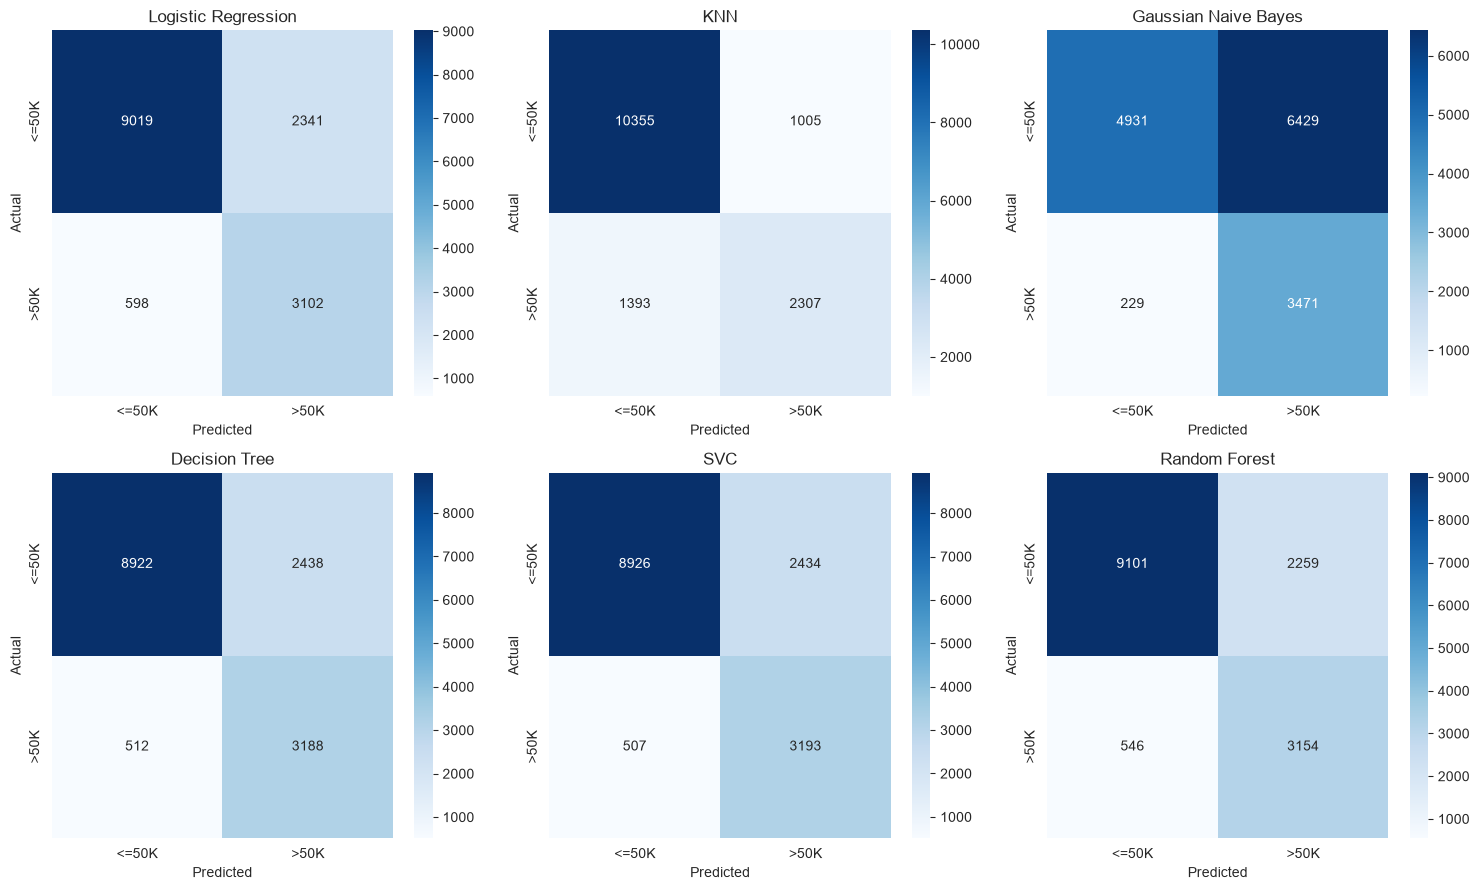

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_le.classes_, yticklabels=target_le.classes_)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

for ax in axes[len(models):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('../models/classification/classification_confusion_matrices.png', dpi=150)
plt.show()

## 12. Full classification report — best model

In [20]:
best_name = comparison_df.index[0]
print(f'Best model: {best_name}')
print(classification_report(y_test, models[best_name].predict(X_test_scaled), target_names=target_le.classes_))

Best model: Gradient Boosting
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91     11360
        >50K       0.78      0.64      0.70      3700

    accuracy                           0.87     15060
   macro avg       0.84      0.79      0.81     15060
weighted avg       0.86      0.87      0.86     15060



## 13. Persist fitted models

In [21]:
import joblib

MODELS_DIR = Path('../models/classification')
MODELS_DIR.mkdir(exist_ok=True)

name_to_file = {
    'Logistic Regression': 'logistic_regression.pkl',
    'KNN': 'knn_classifier.pkl',
    'Gaussian Naive Bayes': 'gaussian_nb.pkl',
    'Decision Tree': 'decision_tree_classifier.pkl',
    'SVC': 'svc.pkl',
}

for name, fname in name_to_file.items():
    joblib.dump(models[name], MODELS_DIR / fname, compress=3)

joblib.dump(scaler, MODELS_DIR / 'classification_scaler.pkl', compress=3)
joblib.dump(ohe, MODELS_DIR / 'classification_onehot_encoder.pkl', compress=3)
joblib.dump(target_le, MODELS_DIR / 'income_label_encoder.pkl', compress=3)
print('saved:', list(name_to_file.values()) + ['classification_scaler.pkl', 'classification_onehot_encoder.pkl', 'income_label_encoder.pkl'])

saved: ['logistic_regression.pkl', 'knn_classifier.pkl', 'gaussian_nb.pkl', 'decision_tree_classifier.pkl', 'svc.pkl', 'classification_scaler.pkl', 'classification_onehot_encoder.pkl', 'income_label_encoder.pkl']


## 14. Save results (metrics tables + plots) to results/classification

In [22]:
import shutil
from pathlib import Path

RESULTS_DIR = Path('../results/classification')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv')
shutil.copy('../models/classification/classification_confusion_matrices.png',
            RESULTS_DIR / 'classification_confusion_matrices.png')

print('saved to', RESULTS_DIR)
print(sorted(p.name for p in RESULTS_DIR.iterdir()))

saved to ../results/classification
['classification_confusion_matrices.png', 'model_comparison.csv']
